# Progetto Q - Analisi statistiche giocatori NBA

In questo notebook analizziamo il dataset `players_stats.csv` con l'obiettivo di
selezionare una coppia di variabili significative e costruire un modello di regressione
lineare e uno non lineare.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

from math import sqrt

## Caricamento del dataset

Carico il file e controllo che i dati siano stati letti correttamente.

In [10]:
df = pd.read_csv("players_stats.csv")
df.head()

,Name,Games Played,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,...,Age,Birth_Place,Birthdate,Collage,Experience,Height,Pos,Team,Weight,BMI
0,AJ Price,26,324,133,51,137,37.2,15,57,26.3,...,29.0,us,"October 7, 1986",University of Connecticut,5,185.0,PG,PHO,81.45,23.798393
1,Aaron Brooks,82,1885,954,344,817,42.1,121,313,38.7,...,30.0,us,"January 14, 1985",University of Oregon,6,180.0,PG,CHI,72.45,22.361111
2,Aaron Gordon,47,797,243,93,208,44.7,13,48,27.1,...,20.0,us,"September 16, 1995",University of Arizona,R,202.5,PF,ORL,99.00,24.142661
3,Adreian Payne,32,740,213,91,220,41.4,1,9,11.1,...,24.0,us,"February 19, 1991",Michigan State University,R,205.0,PF,ATL,106.65,25.377751
4,Al Horford,76,2318,1156,519,965,53.8,11,36,30.6,...,29.0,do,"June 3, 1986",University of Florida,7,205.0,C,ATL,110.25,26.234384


## Colonne disponibili

Verifico i nomi delle colonne per individuare le variabili numeriche su cui lavorare.

In [11]:
print(df.columns.tolist())


['Name', 'Games Played', 'MIN', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'EFF', 'AST/TOV', 'STL/TOV', 'Age', 'Birth_Place', 'Birthdate', 'Collage', 'Experience', 'Height', 'Pos', 'Team', 'Weight', 'BMI']


## Matrice di correlazione

Calcolo la matrice di correlazione tra tutte le variabili numeriche per individuare le relazioni più forti.

In [12]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix

,Games Played,MIN,PTS,FGM,FGA,FG%,3PM,3PA,3P%,FTM,...,BLK,TOV,PF,EFF,AST/TOV,STL/TOV,Age,Height,Weight,BMI
Games Played,1.000000,0.872959,0.727973,0.739667,0.741407,0.369492,0.492036,0.510728,0.218361,0.575342,...,0.459709,0.693894,0.860430,0.757467,0.169564,0.012988,0.139838,0.068284,0.080360,0.065185
MIN,0.872959,1.000000,0.920196,0.924123,0.926747,0.304910,0.601725,0.618675,0.278590,0.775022,...,0.499512,0.858630,0.872932,0.923723,0.198229,-0.045213,0.087547,0.009521,0.033385,0.052763
PTS,0.727973,0.920196,1.000000,0.990487,0.988716,0.275514,0.615766,0.627413,0.290644,0.909402,...,0.445102,0.883540,0.753363,0.941961,0.166571,-0.102540,0.063428,-0.016891,0.030831,0.078018
FGM,0.739667,0.924123,0.990487,1.000000,0.986789,0.310255,0.548751,0.560697,0.254783,0.868013,...,0.488795,0.872757,0.775502,0.951369,0.147698,-0.111683,0.065786,0.026565,0.077724,0.105658
FGA,0.741407,0.926747,0.988716,0.986789,1.000000,0.231871,0.624375,0.646638,0.309729,0.865389,...,0.406254,0.886276,0.757420,0.915277,0.195855,-0.100390,0.061307,-0.047915,0.002796,0.067171
FG%,0.369492,0.304910,0.275514,0.310255,0.231871,1.000000,-0.045385,-0.070072,-0.097218,0.235433,...,0.419133,0.226864,0.375768,0.383651,-0.124186,-0.064153,0.089074,0.366599,0.383616,0.216849
3PM,0.492036,0.601725,0.615766,0.548751,0.624375,-0.045385,1.000000,0.988563,0.537028,0.443760,...,-0.058761,0.495797,0.389995,0.453904,0.289378,0.065442,0.074057,-0.301668,-0.304422,-0.153515
3PA,0.510728,0.618675,0.627413,0.560697,0.646638,-0.070072,0.988563,1.000000,0.531573,0.462710,...,-0.065263,0.526029,0.407298,0.457740,0.308285,0.068205,0.060393,-0.324040,-0.326490,-0.164209
3P%,0.218361,0.278590,0.290644,0.254783,0.309729,-0.097218,0.537028,0.531573,1.000000,0.189836,...,-0.196782,0.221739,0.099524,0.160524,0.349797,0.101430,0.013422,-0.355749,-0.425045,-0.306359
FTM,0.575342,0.775022,0.909402,0.868013,0.865389,0.235433,0.443760,0.462710,0.189836,1.000000,...,0.415265,0.836937,0.623557,0.859884,0.112697,-0.126039,0.028665,-0.007247,0.040284,0.082334


## Heatmap delle correlazioni

Per avere una visione globale delle relazioni tra le variabili numeriche, rappresento la matrice di correlazione con una heatmap.


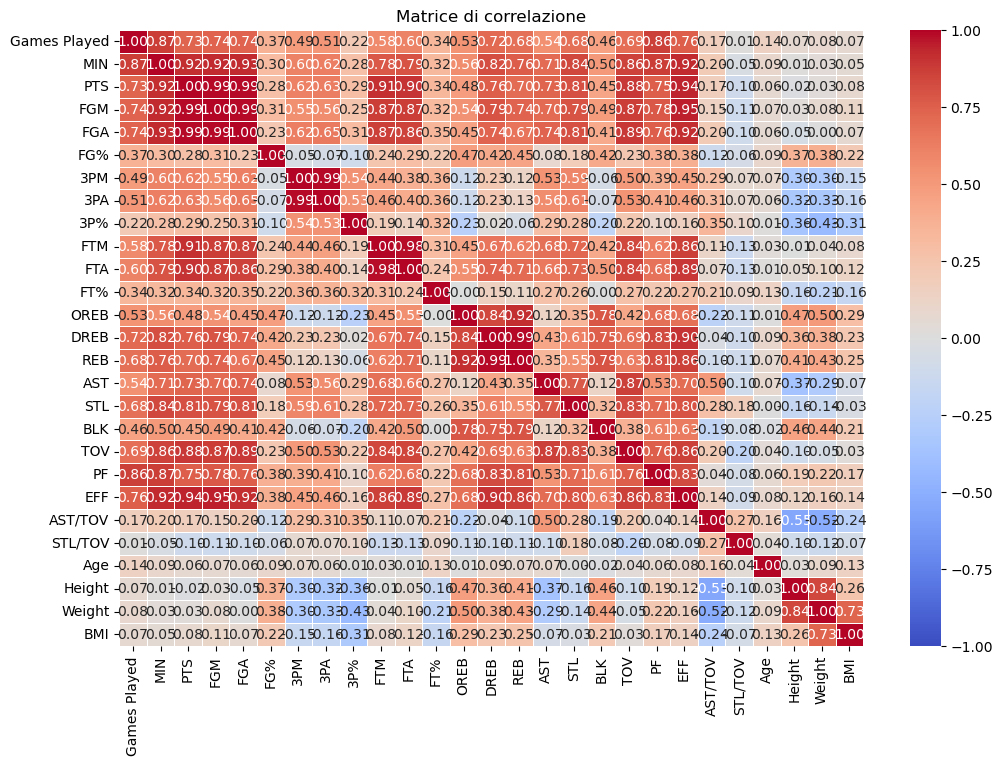

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Matrice di correlazione")
plt.show()

## Analisi delle correlazioni

Calcolo la matrice di correlazione tra le feature numeriche per individuare coppie di variabili fortemente correlate.

In [14]:
corr_abs = corr_matrix.abs()

pairs=[]
cols=corr_abs.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        var1=cols[i]
        var2=cols[j]
        corr_value=corr_abs.loc[var1,var2]
        pairs.append((var1,var2,corr_value))
pairs_df=pd.DataFrame(pairs,columns=['Variable 1','Variable 2','Correlation'])
pairs_df_sorted=pairs_df.sort_values(by='Correlation',ascending=False).dropna()
print(pairs_df_sorted.head(15).to_string(index=False))

Variable 1 Variable 2  Correlation
       PTS        FGM     0.990487
       PTS        FGA     0.988716
       3PM        3PA     0.988563
       FGM        FGA     0.986789
      DREB        REB     0.985036
       FTM        FTA     0.981130
       FGM        EFF     0.951369
       PTS        EFF     0.941961
       MIN        FGA     0.926747
       MIN        FGM     0.924123
       MIN        EFF     0.923723
      OREB        REB     0.921286
       MIN        PTS     0.920196
       FGA        EFF     0.915277
       PTS        FTM     0.909402


## Analisi delle correlazioni principali

La tabella soprastante mostra le 15 coppie di variabili con la correlazione più elevata in valore assoluto.
Dall'analisi emerge che la coppia `FGM` e `PTS` presenta una correlazione molto alta.

Per questo motivo seleziono:
- `FGM` come variabile indipendente;
- `PTS` come variabile dipendente.

Questa scelta è coerente anche dal punto di vista interpretativo, poiché i field goals realizzati
contribuiscono direttamente al numero totale di punti segnati.

## Definizione delle variabili per la regressione

Imposto `FGM` come input del modello e `PTS` come variabile target.

In [15]:
X=df[["FGM"]] 
y=df[["PTS"]]
print("shape di X", X.shape)
print("shape di y", y.shape)
print("Prime 5 righe di X")
print(X.head().to_string(index=False))
print("Prime 5 righe di y") #ver
print(y.head().to_string(index=False))

shape di X (490, 1)
shape di y (490, 1)
Prime 5 righe di X
 FGM
  51
 344
  93
  91
 519
Prime 5 righe di y
 PTS
 133
 954
 243
 213
1156


## Modello di Regressione Lineare
Si applica il modello di Regressione Lineare alle due variabili `FGM` e `PTS` appena definite.
Il coefficiente angolare della retta di regressione e la sua intercetta forniscono informazioni su `PTS` in funzione di `FGM`, permettendone la comprensione mediante il semplice calcolo dell'equazione di una retta.

In [16]:
model = LinearRegression()
model.fit(X, y)
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)
y_pred = model.predict(X)

Slope: [2.67537225]
Intercept: [-1.76817008]


## Scatter Plot per la Regressione
Per visualizzare il modello in azione sui dati, si rappresenta con uno scatter plot la retta di regressione.

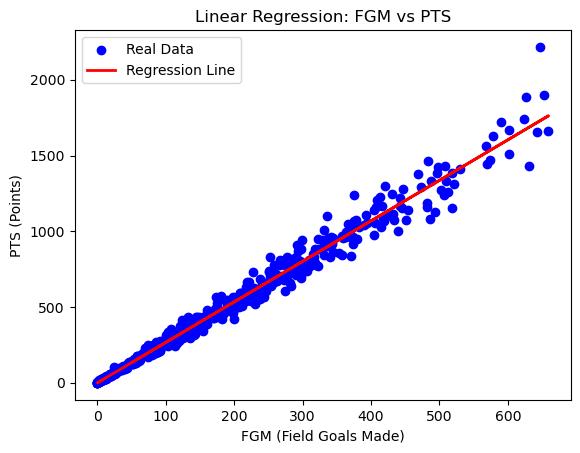

In [17]:
plt.scatter(X, y, color = "blue", label = "Real Data")
plt.plot(X, y_pred, color = "red", linewidth = 2, label = "Regression Line")
plt.xlabel("FGM (Field Goals Made)")
plt.ylabel("PTS (Points)")
plt.title("Linear Regression: FGM vs PTS")
plt.legend()
plt.show()

## Performance del modello
Si calcola il Coefficiente di Determinazione per misurare quanta parte della varianza è spiegata correttamente dal modello.

In [18]:
r2 = r2_score(y, y_pred)
print(f"Coefficient of Determination (R²): {r2:.4f}")


Coefficient of Determination (R²): 0.9811


## Modello di Regressione non Lineare
Si applica ora un modello di Regressione non Lineare sulle due variabili `FGM` e `PTS` per stabilire un confronto delle performance col modello di Regressione Lineare, mettendo a confronto anche graficamente i due modelli con uno scatter plot. 

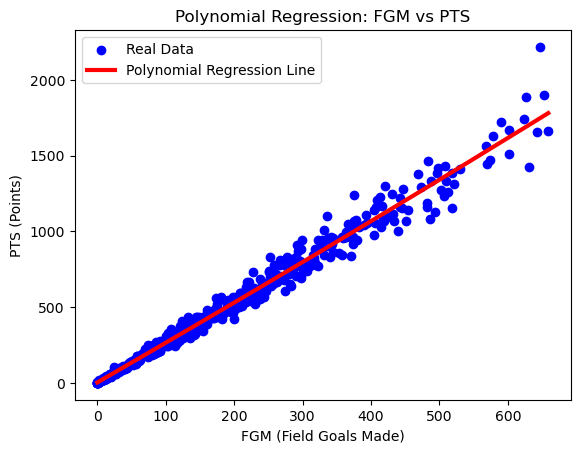

In [19]:
polynomial = PolynomialFeatures(degree = 2)
X_poly = polynomial.fit_transform(X)
poly_model = LinearRegression()
poly_model.fit(X_poly, y)
y_poly_pred = poly_model.predict(X_poly)
sorted_zip = sorted(zip(X.values, y_poly_pred))
x_plot, y_plot = zip(*sorted_zip)
plt.scatter(X, y, color = "blue", label = "Real Data")
plt.plot(x_plot, y_plot, color = "red", linewidth = 3, label = "Polynomial Regression Line")
plt.xlabel("FGM (Field Goals Made)")
plt.ylabel("PTS (Points)")
plt.title("Polynomial Regression: FGM vs PTS")
plt.legend()
plt.show()

## Coefficiente di Determinazione
Anche per il modello Polinomiale si calcola il Coefficente di Determinazione.

In [20]:
r2 = r2_score(y, y_pred)
print(f" Coefficient of Determination (R²): {r2:.4f}")

 Coefficient of Determination (R²): 0.9811


## Analisi e considerazioni
L'applicazione di un modello di Regressione Polinomiale genera risultati esattamente sovrapponibili a quelli del modello Lineare (i coefficienti dei termini di grado superiore risultano trascurabili). Ciò conferma che la relazione tra `FGM` e `PTS` è intrinsecamente lineare. L'analisi visiva dello scatter plot conferma l'assenza di curvature o variazioni di tendenza, pertanto, l'adozione di modelli non lineari più complessi comporterebbe solo un inutile aumento della varianza del modello senza benefici in termini di varianza spiegata ($R^2$).

___
## Training modello di regressione lineare

In [21]:
# Splitting the dataset into the Training set and Test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 25)

print("Shape of X_train: ",X_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_test",y_test.shape)

Shape of X_train:  (245, 1)
Shape of X_test:  (245, 1)
Shape of y_train:  (245, 1)
Shape of y_test (245, 1)


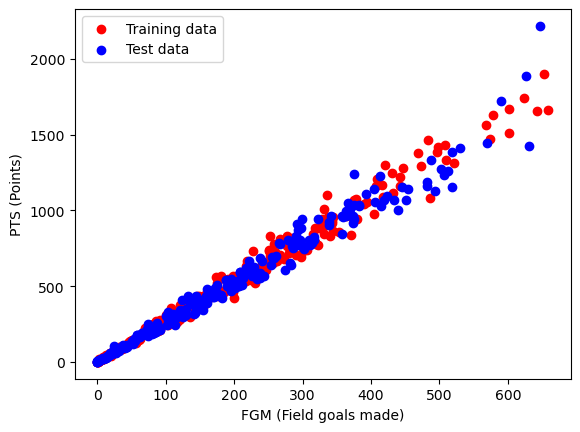

In [22]:
plt.scatter(X_train, y_train, color='red', label='Training data')
plt.scatter(X_test, y_test, color='blue', label='Test data')
plt.legend()
plt.ylabel('PTS (Points)')
plt.xlabel('FGM (Field goals made)')
plt.show()

In [23]:
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

LinearRegression()

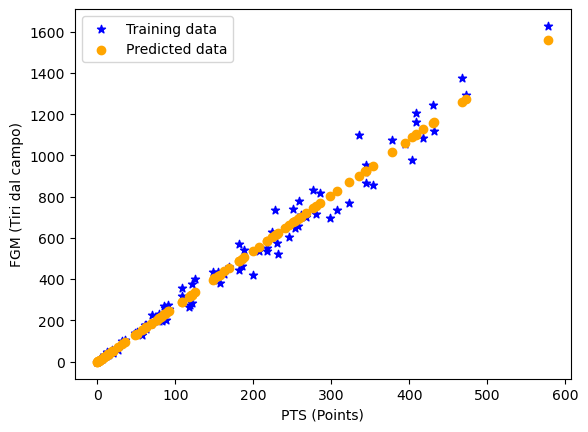

In [24]:
# Training data prediction
y_prediction = linear_regression.predict(X_train)

plt.scatter(X_train[:100], y_train[:100], color='blue', label='Training data', marker='*')
plt.scatter(X_train[:100], y_prediction[:100], color='orange', label='Predicted data')

plt.legend()
plt.xlabel('PTS (Points)')
plt.ylabel('FGM (Tiri dal campo)')
plt.show()

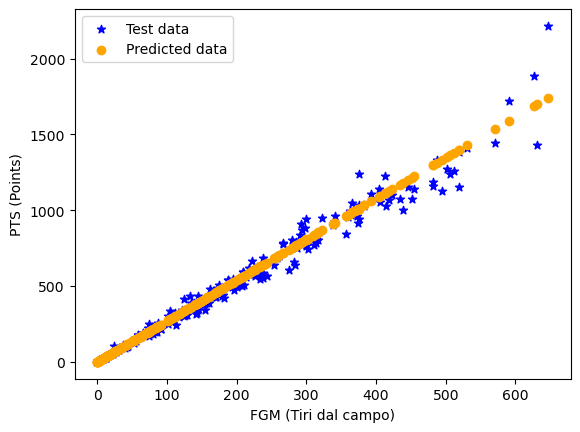

In [25]:
# Test data prediction
y_test_prediction = linear_regression.predict(X_test)

plt.scatter(X_test, y_test, color='blue', label='Test data', marker='*')
plt.scatter(X_test, y_test_prediction, color='orange', label='Predicted data')

plt.legend()
plt.ylabel('PTS (Points)')
plt.xlabel('FGM (Tiri dal campo)')
plt.show()

__*Calcoliamo le metriche $R^2$ e RMSE, per verificare la precisione del modello*__

In [26]:
print(f"Punteggio R2: {r2_score(y_test, y_test_prediction):.2f}")
MSE = mean_squared_error(y_test, y_test_prediction)
RMSE = (sqrt(MSE))

print(f"Root mean Squared Error: {RMSE:.2f}")

max_value = y_test.values.max()
min_value = y_test.values.min()
print(f"In a range from {min_value} to {max_value}")

Punteggio R2: 0.97
Root mean Squared Error: 63.98
In a range from 0 to 2217


### __Grafico dei sample__

Text(0.5, 0, 'Samples')

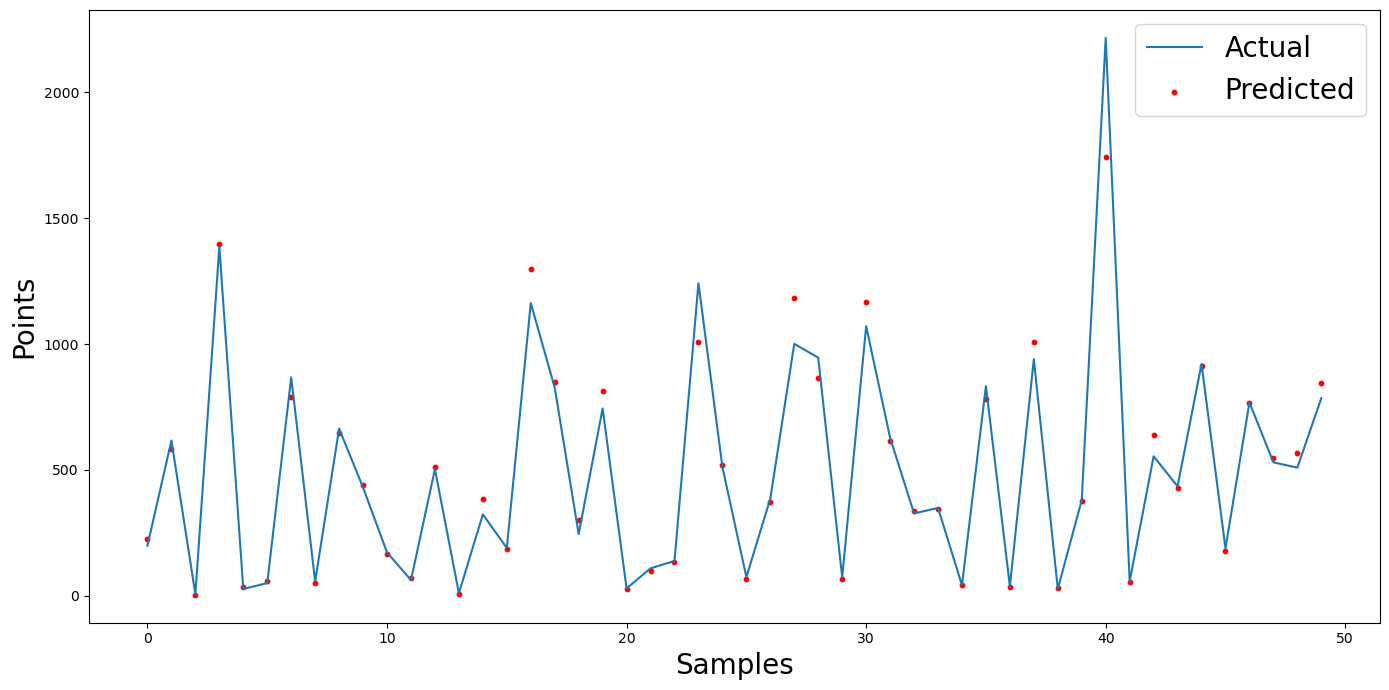

In [27]:
# fig, axes = plt.subplots(ncols=1, figsize=(28,14))
plt.figure(figsize=(14, 7), tight_layout=True)

plt.plot(range(50), y_test[:50], label='Actual')
plt.scatter(range(50), y_test_prediction[:50], label='Predicted', c='red', s=10)

plt.legend(fontsize=20)

plt.ylabel("Points", fontsize=20)
plt.xlabel("Samples", fontsize=20)

___
## Training modello di regressione non lineare

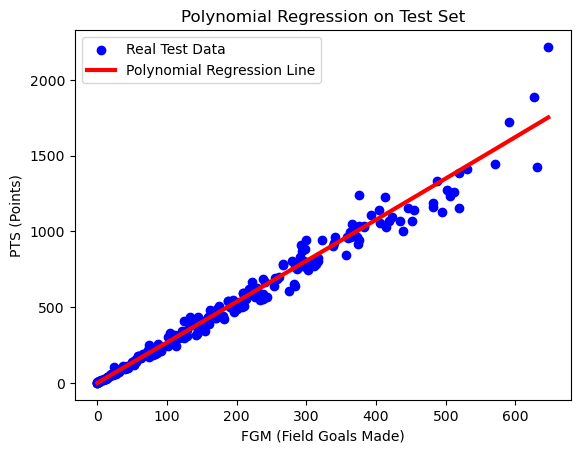

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.5, random_state = 25)


polynomial = PolynomialFeatures(degree = 2)

X_poly = polynomial.fit_transform(X_train)

X_test_poly = polynomial.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_poly, y_train)

y_poly_prediction = poly_model.predict(X_test_poly)

# Plotting the results
sorted_zip = sorted(zip(X_test.values, y_poly_prediction))
x_plot, y_plot = zip(*sorted_zip)

plt.scatter(X_test, y_test, color = "blue", label = "Real Test Data")
plt.plot(x_plot, y_plot, color = "red", linewidth = 3, label = "Polynomial Regression Line")
plt.xlabel("FGM (Field Goals Made)")
plt.ylabel("PTS (Points)")
plt.title("Polynomial Regression on Test Set")
plt.legend()
plt.show()

__Performance del modello__

In [29]:
print(f"Punteggio R2: {r2_score(y_test, y_poly_prediction):.2f}")
MSE = mean_squared_error(y_test, y_poly_prediction)
RMSE = (sqrt(MSE))

print(f"Root mean Squared Error: {RMSE:.2f}")

max_value = y_test.values.max()
min_value = y_test.values.min()
print(f"In a range from {min_value} to {max_value}")

Punteggio R2: 0.97
Root mean Squared Error: 63.82
In a range from 0 to 2217


## 4. Valutazione delle prestazioni



In [33]:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt

# Prestazioni Modello Lineare
mse_linear = mean_squared_error(y_test, y_test_prediction)
rmse_linear = sqrt(mse_linear)
mae_linear = mean_absolute_error(y_test, y_test_prediction)
r2_linear = r2_score(y_test, y_test_prediction)

# Prestazioni Modello Polinomiale
mse_poly = mean_squared_error(y_test, y_poly_prediction)
rmse_poly = sqrt(mse_poly)
mae_poly = mean_absolute_error(y_test, y_poly_prediction)
r2_poly = r2_score(y_test, y_poly_prediction)

# Tabella Comparison
comparison = pd.DataFrame({
    "Modello": ["Lineare", "Polinomiale grado 2"],
    "MSE": [mse_linear, mse_poly],
    "RMSE": [rmse_linear, rmse_poly],
    "R2": [r2_linear, r2_poly],
    "MAE": [mae_linear, mae_poly]
})

comparison


,Modello,MSE,RMSE,R2,MAE
0,Lineare,4093.194920,63.978082,0.974613,37.037568
1,Polinomiale grado 2,4072.584471,63.816804,0.974741,36.859238


Per confrontare le prestazioni dei due modelli sulla parte di test vengono considerate diverse metriche: $R^2$, MSE, RMSE e MAE.

Il coefficiente di determinazione $R^2$ misura quanta parte della variabilità della variabile target 'PTS' viene spiegata dal modello: valori vicini a 1 indicano una buona capacità predittiva.

Il MSE, ossia Mean Squared Error, misura la media degli errori al quadrato. Questa metrica penalizza principalmente gli errori più grandi.

Il RMSE, ossia Root Mean Squared Error, è la radice quadrata del MSE ed è espresso nella stessa unità della variabile target, quindi in punti. Valori più bassi indicano previsioni più accurate.

Il MAE, cioè Mean Absolute Error, misura l'errore medio assoluto tra valori reali e valori previsti. Anche in questo caso valori più bassi indicano un modello migliore.

| Modello | $R^2$ | MSE | RMSE | MAE |
| --- | ---: | ---: | ---: | ---: |
| Regressione lineare | 0.97 | 4093.19 | 63.98 | 37.03 |
| Regressione polinomiale di grado 2 | 0.97 | 4072.58 | 63.82 | 36.86 |

I risultati mostrano che entrambi i modelli ottengono un valore di $R^2$ pari a circa 0.97. Questo significa che sia il modello lineare sia quello polimoniale riescono a spiegare molto bene la relazione tra 'FGM' e 'PTS' sui dati di test.

Osservando le metriche di errore, si nota che i valori di MSE, RMSE, e MAE sono molto simili per entrambi i modelli. Il modello polinomiale presenta un RMSE leggermente inferiore rispetto al lineare, ma la differenza è minima e non indica un miglioramento realmente significativo.

Di conseguenza, il modello polinomiale non porta un vantaggio immportante rispetto al modello lineare. Poichè il modello lineare ha prestazioni praticamente equivalenti, ma è più semplice e più interpretabile, risulta l'approccio preferibile per qeusto problema.
